In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted.")

Mounted at /content/drive
Google Drive mounted.


In [ ]:
import json
import os
import ast

def extract_classes_from_notebook(path, class_names):
    with open(path, 'r', encoding='utf-8') as f:
        nb = json.load(f)
    full_code = ""
    for cell in nb['cells']:
        if cell['cell_type'] == 'code':
            full_code += "".join(cell['source']) + "\n"
    tree = ast.parse(full_code)
    class_defs = [node for node in tree.body if isinstance(node, ast.ClassDef) and (node.name in class_names or 'Block' in node.name)]
    new_tree = ast.Module(body=class_defs, type_ignores=[])
    namespace = {}
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    namespace.update({'torch': torch, 'nn': nn, 'F': F})
    exec(compile(new_tree, filename="<ast>", mode="exec"), namespace)
    return {name: namespace.get(name) for name in class_names}
## the whole extract classes function was written by Gemini

notebook_dir = '/content/drive/MyDrive/cs320/final project/'

try:
    lenet_data = extract_classes_from_notebook(os.path.join(notebook_dir, 'LeNet-5.ipynb'), ['LeNet5', 'RBFLayer'])
    resnet_data = extract_classes_from_notebook(os.path.join(notebook_dir, 'Resnet.ipynb'), ['ResidualCNN', 'ResidualBlock'])
    modern_data = extract_classes_from_notebook(os.path.join(notebook_dir, 'Modern CNN.ipynb'), ['ModernCNN'])

    RBFLayer = lenet_data['RBFLayer']
    LeNet5RBF = lenet_data['LeNet5']
    ResidualCNN = resnet_data['ResidualCNN']
    ModernCNN = modern_data['ModernCNN']

except Exception as e:
    print(f"Extraction failed: {e}")

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

# Global transformations
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
]) ## this section written by Gemini

def get_dataloaders(split_name, batch_size=64):
    train_dataset = torchvision.datasets.EMNIST(
        root='./data', train=True, split=split_name, download=True, transform=transform
    )
    test_dataset = torchvision.datasets.EMNIST(
        root='./data', train=False, split=split_name, download=True, transform=transform
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Determine number of classes from the dataset labels
    num_classes = len(train_dataset.classes)
    return train_loader, test_loader, num_classes

print("DataLoader utility function defined.")

DataLoader utility function defined.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader, device, classes):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy()) ## Written by Gemini
            all_labels.extend(labels.cpu().numpy()) ## Written by Gemini

    cm = confusion_matrix(all_labels, all_preds)
    # Normalize the confusion matrix by row (actual class)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_normalized, annot=False, fmt='.2%', cmap='Blues', xticklabels=classes, yticklabels=classes) ## Written by Gemini
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Normalized Confusion Matrix')

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def save_activations(module, input, output):
            self.activations = output
        def save_gradients(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        ##### From here to the end of this cell written with Gemini Autocomplete ######
        target_layer.register_forward_hook(save_activations)
        target_layer.register_backward_hook(save_gradients)

    def generate(self, input_image, target_class):
        output = self.model(input_image)
        self.model.zero_grad()
        output[0, target_class].backward()

        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        cam = np.maximum(cam.detach().cpu().numpy(), 0)
        cam = cam / np.max(cam)
        return cam
        #############################################################



--- Evaluating lenet5_rbf Model on: balanced ---
Saved Confusion Matrix to: /content/drive/MyDrive/cs320/final project/figures/lenet5_rbf_balanced_confusion_matrix.png


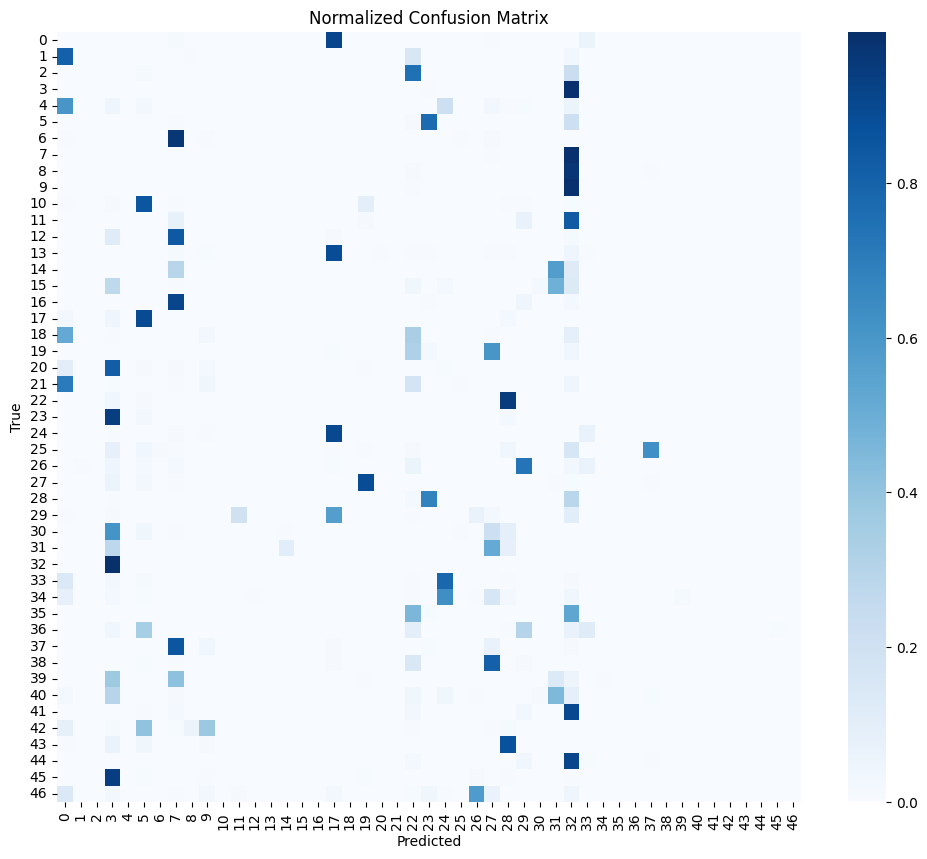

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved Grad-CAM to: /content/drive/MyDrive/cs320/final project/figures/lenet5_rbf_balanced_gradcam.png


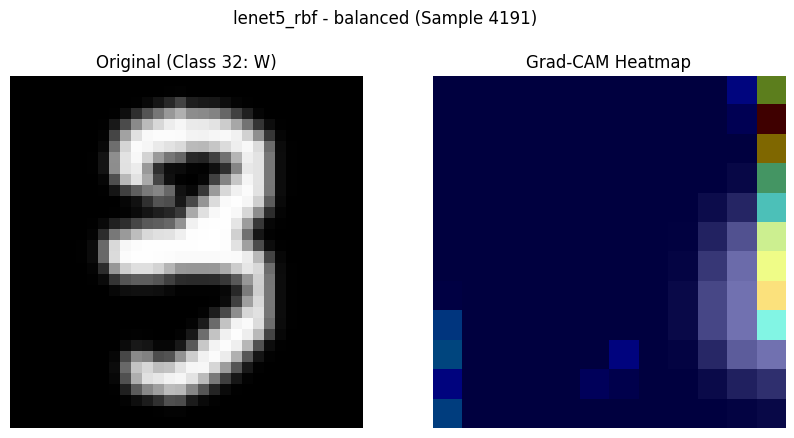


--- Evaluating lenet5_rbf Model on: byclass ---
Saved Confusion Matrix to: /content/drive/MyDrive/cs320/final project/figures/lenet5_rbf_byclass_confusion_matrix.png


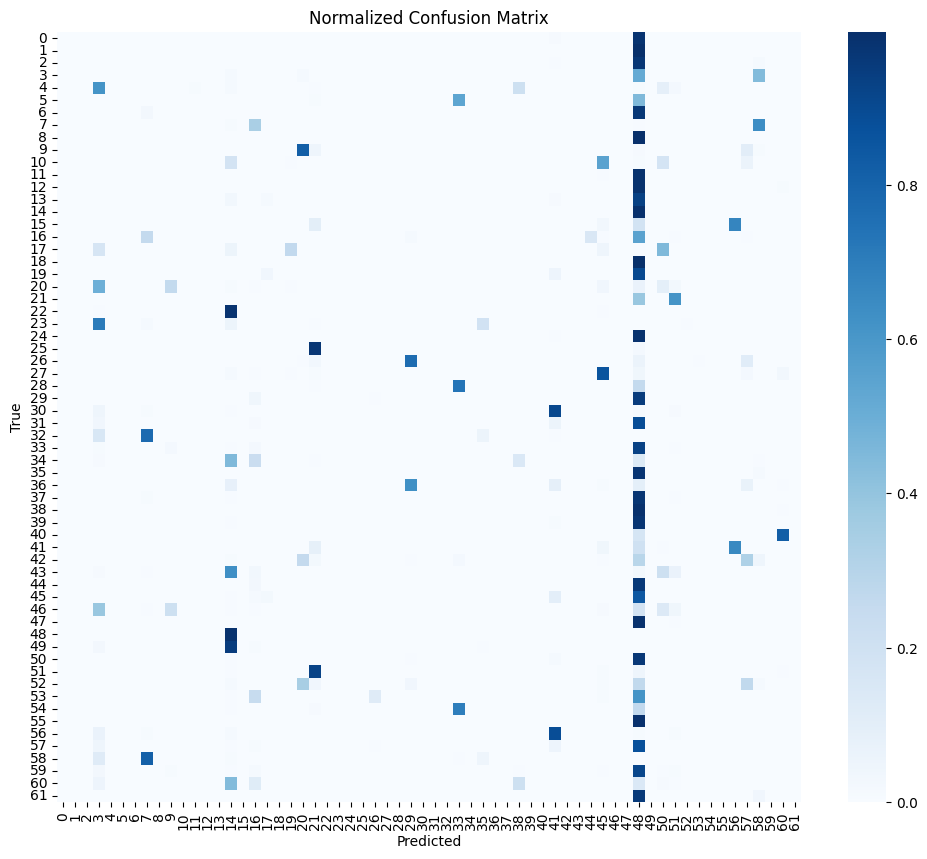

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved Grad-CAM to: /content/drive/MyDrive/cs320/final project/figures/lenet5_rbf_byclass_gradcam.png


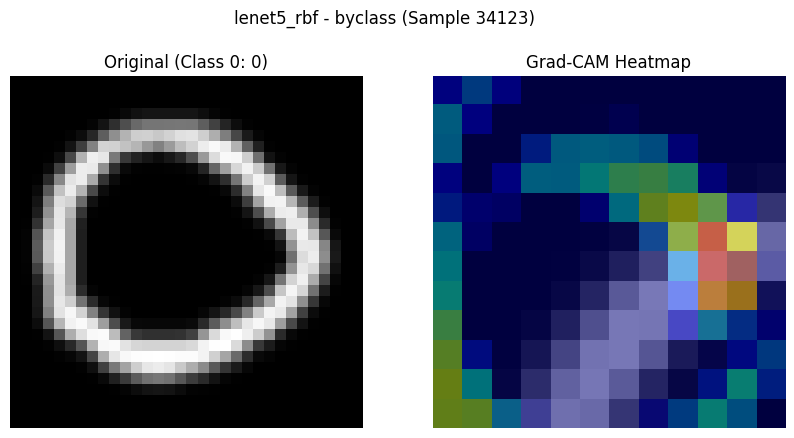


--- Evaluating lenet5_rbf Model on: bymerge ---
Saved Confusion Matrix to: /content/drive/MyDrive/cs320/final project/figures/lenet5_rbf_bymerge_confusion_matrix.png


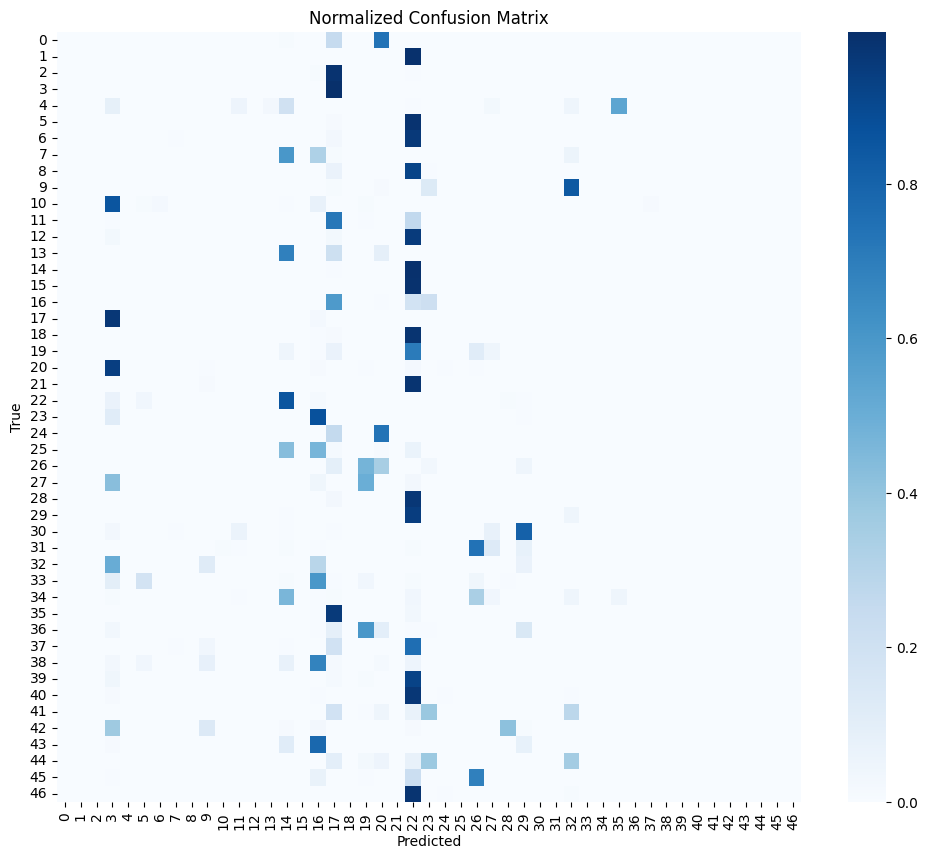

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved Grad-CAM to: /content/drive/MyDrive/cs320/final project/figures/lenet5_rbf_bymerge_gradcam.png


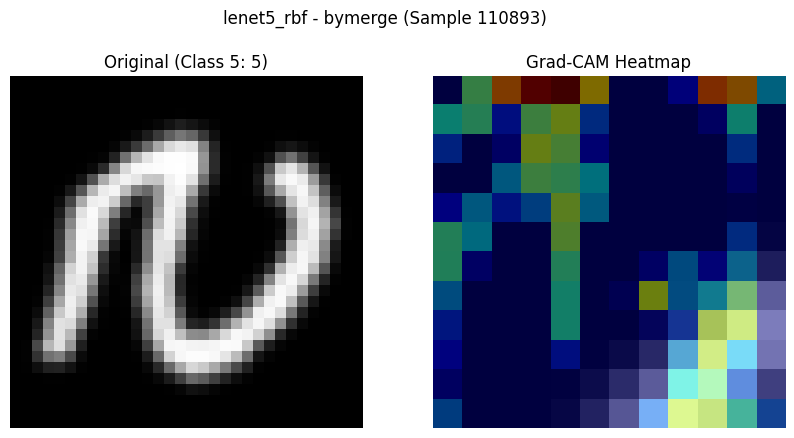


--- Evaluating resnet Model on: balanced ---
Saved Confusion Matrix to: /content/drive/MyDrive/cs320/final project/figures/resnet_balanced_confusion_matrix.png


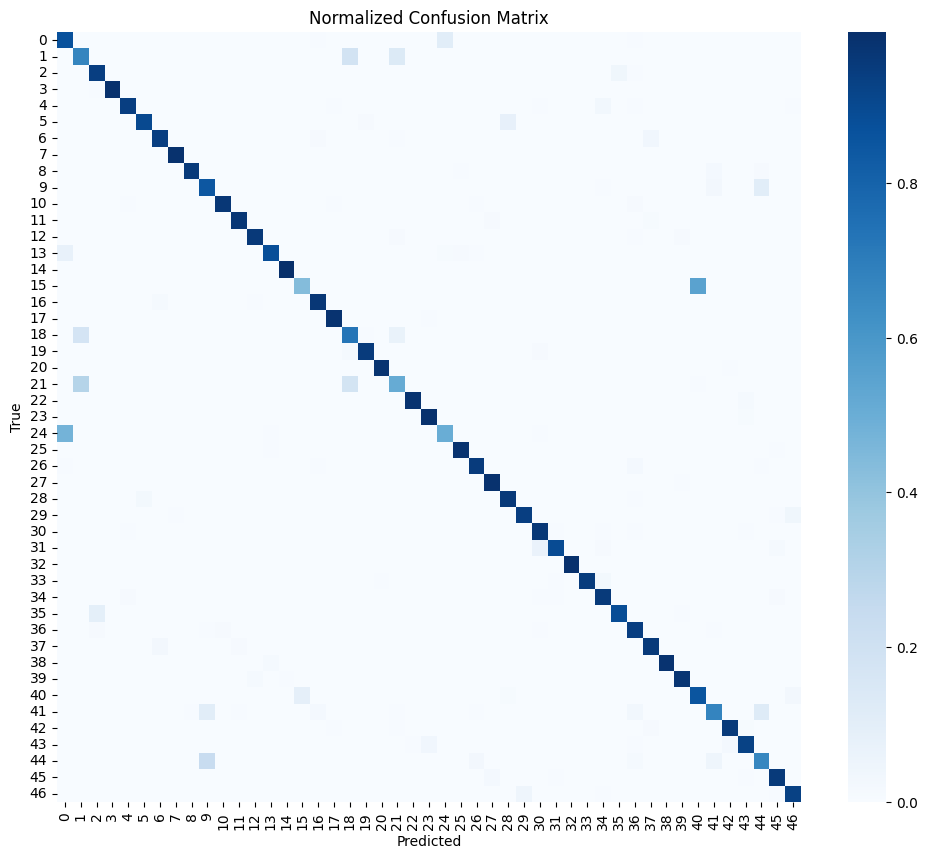

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved Grad-CAM to: /content/drive/MyDrive/cs320/final project/figures/resnet_balanced_gradcam.png


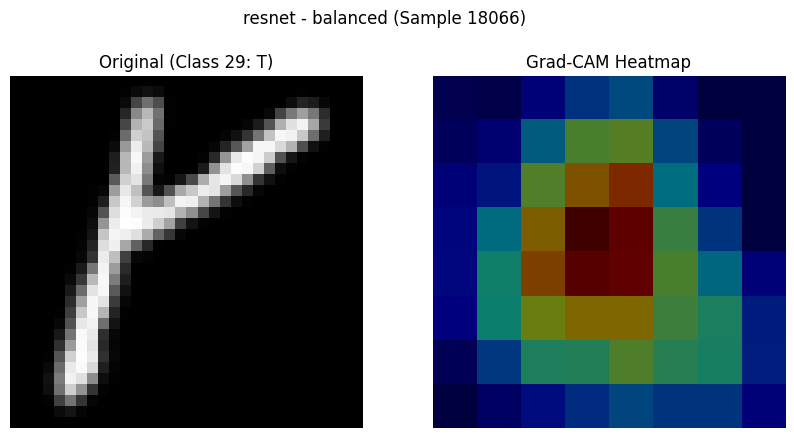


--- Evaluating resnet Model on: byclass ---
Saved Confusion Matrix to: /content/drive/MyDrive/cs320/final project/figures/resnet_byclass_confusion_matrix.png


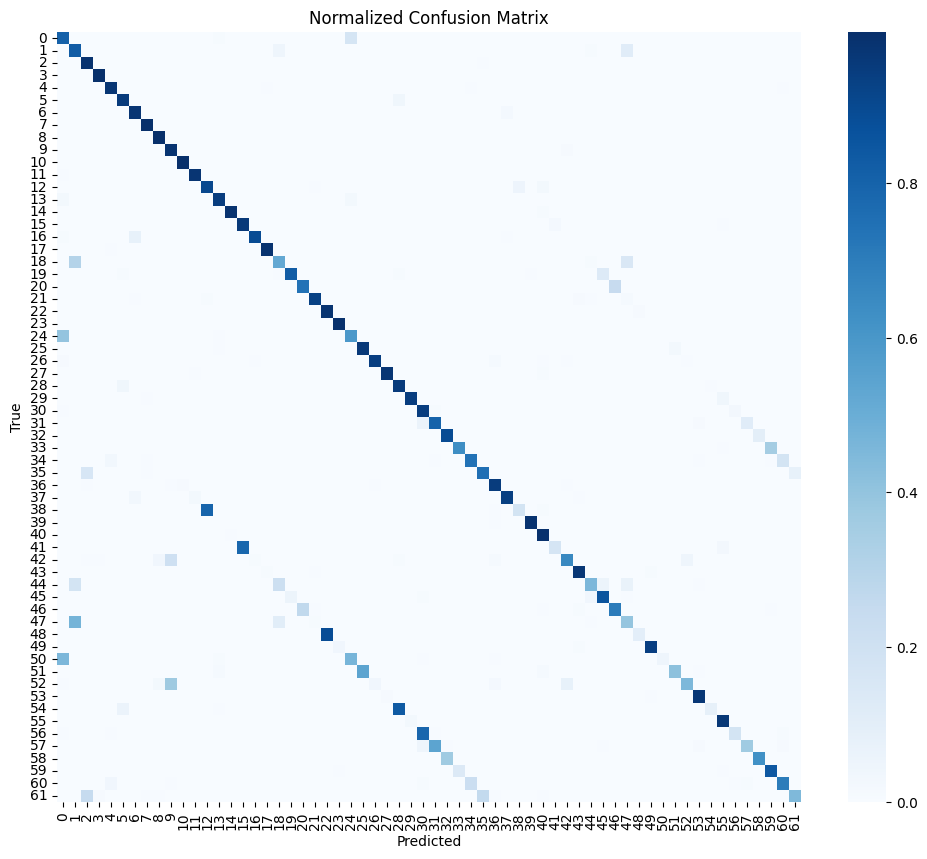

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved Grad-CAM to: /content/drive/MyDrive/cs320/final project/figures/resnet_byclass_gradcam.png


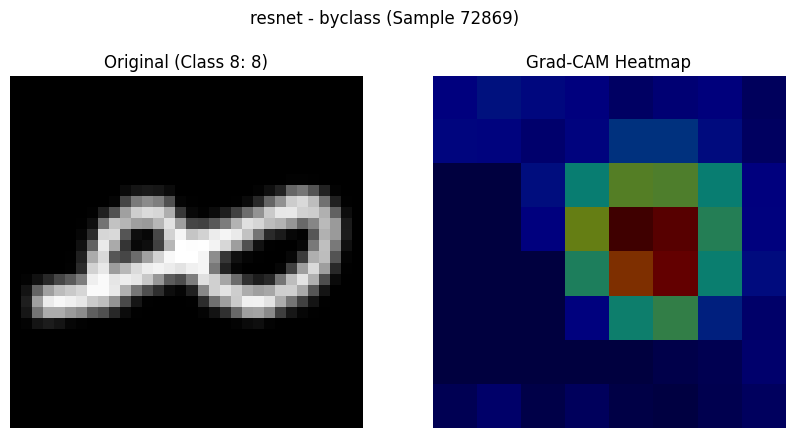


--- Evaluating resnet Model on: bymerge ---
Saved Confusion Matrix to: /content/drive/MyDrive/cs320/final project/figures/resnet_bymerge_confusion_matrix.png


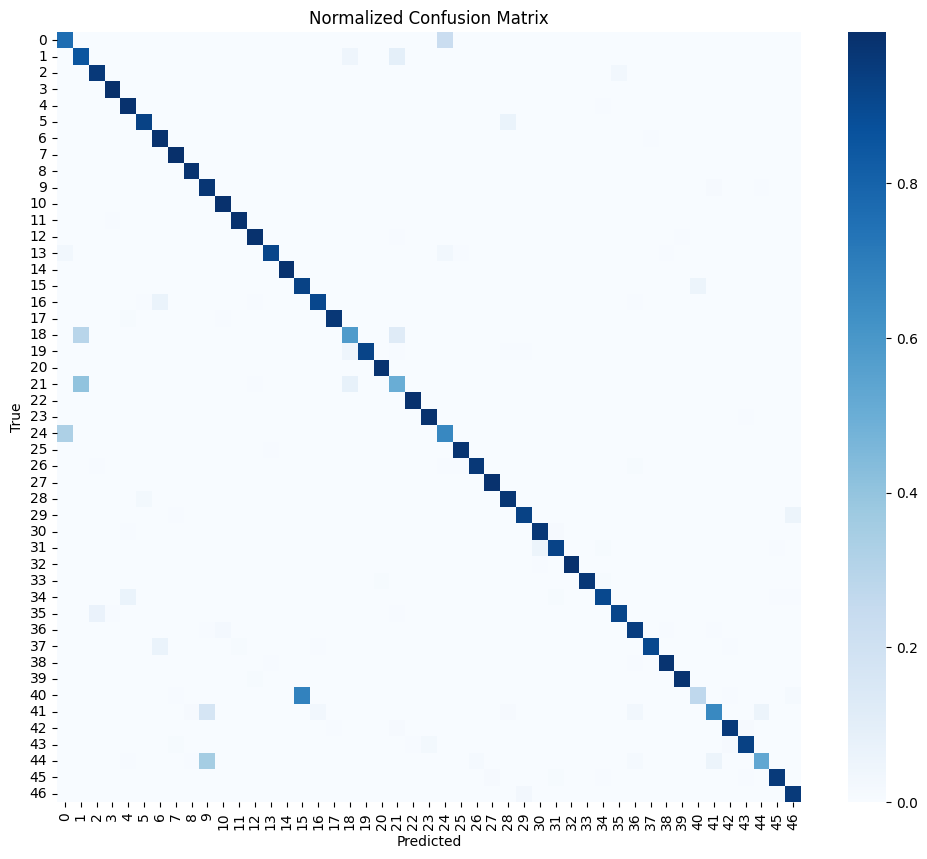

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved Grad-CAM to: /content/drive/MyDrive/cs320/final project/figures/resnet_bymerge_gradcam.png


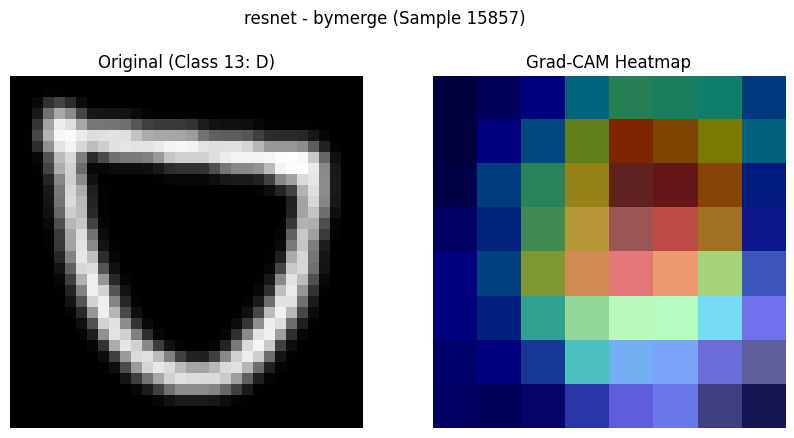


--- Evaluating modern Model on: balanced ---
Saved Confusion Matrix to: /content/drive/MyDrive/cs320/final project/figures/modern_balanced_confusion_matrix.png


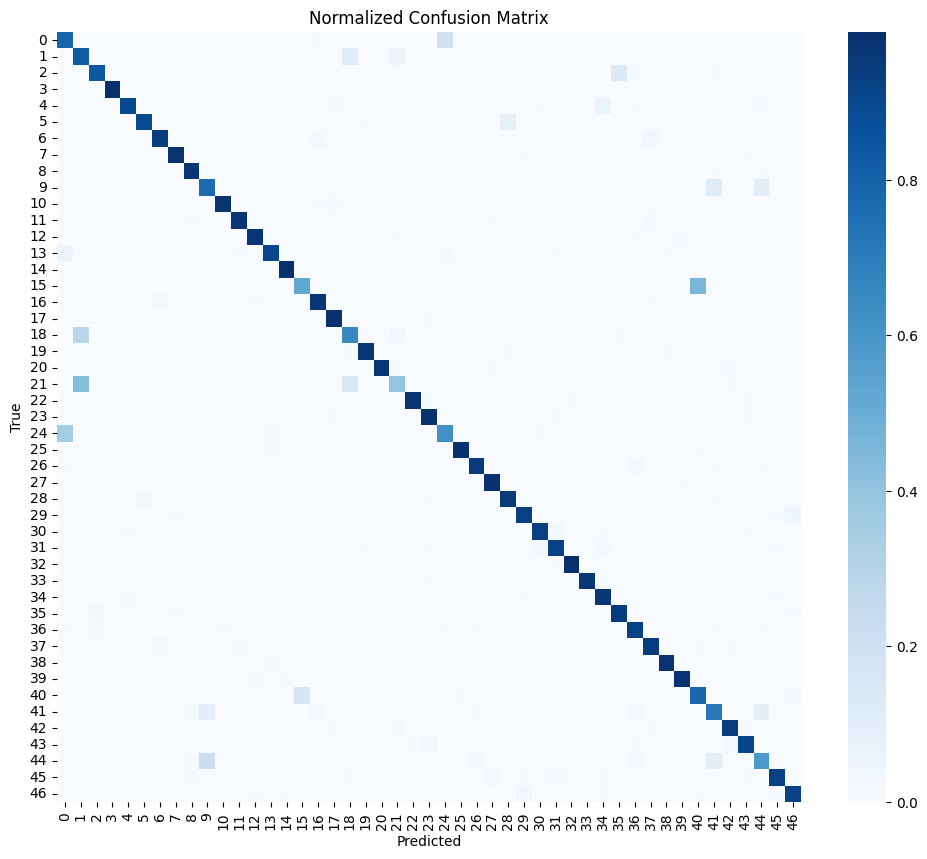

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/tmp/ipykernel_6764/1183487980.py:25: RuntimeWarning: invalid value encountered in divide
  cam = cam / np.max(cam)


Saved Grad-CAM to: /content/drive/MyDrive/cs320/final project/figures/modern_balanced_gradcam.png


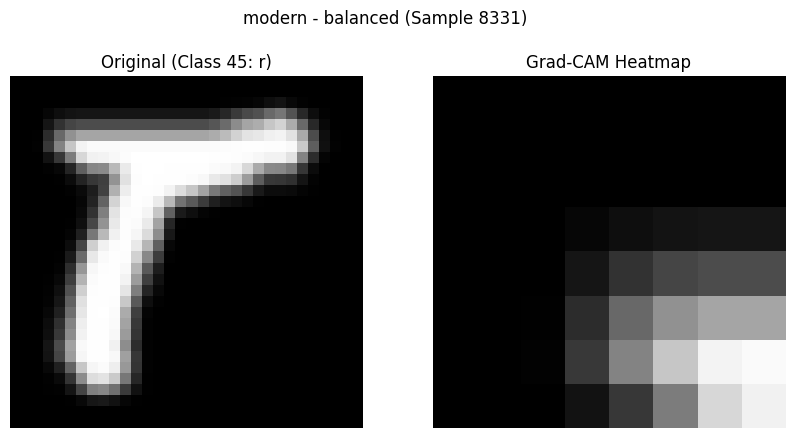


--- Evaluating modern Model on: byclass ---
Saved Confusion Matrix to: /content/drive/MyDrive/cs320/final project/figures/modern_byclass_confusion_matrix.png


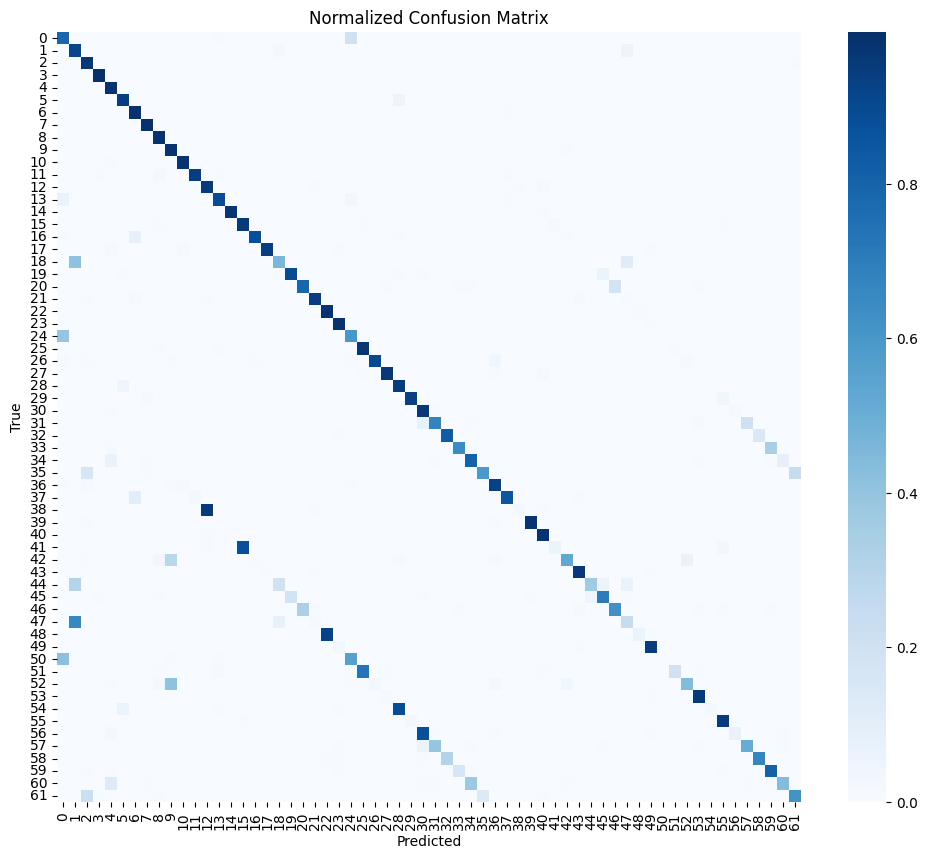

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved Grad-CAM to: /content/drive/MyDrive/cs320/final project/figures/modern_byclass_gradcam.png


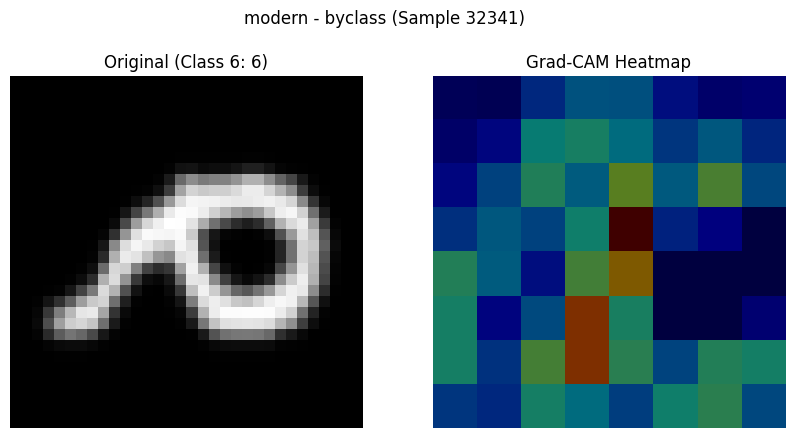


--- Evaluating modern Model on: bymerge ---
Saved Confusion Matrix to: /content/drive/MyDrive/cs320/final project/figures/modern_bymerge_confusion_matrix.png


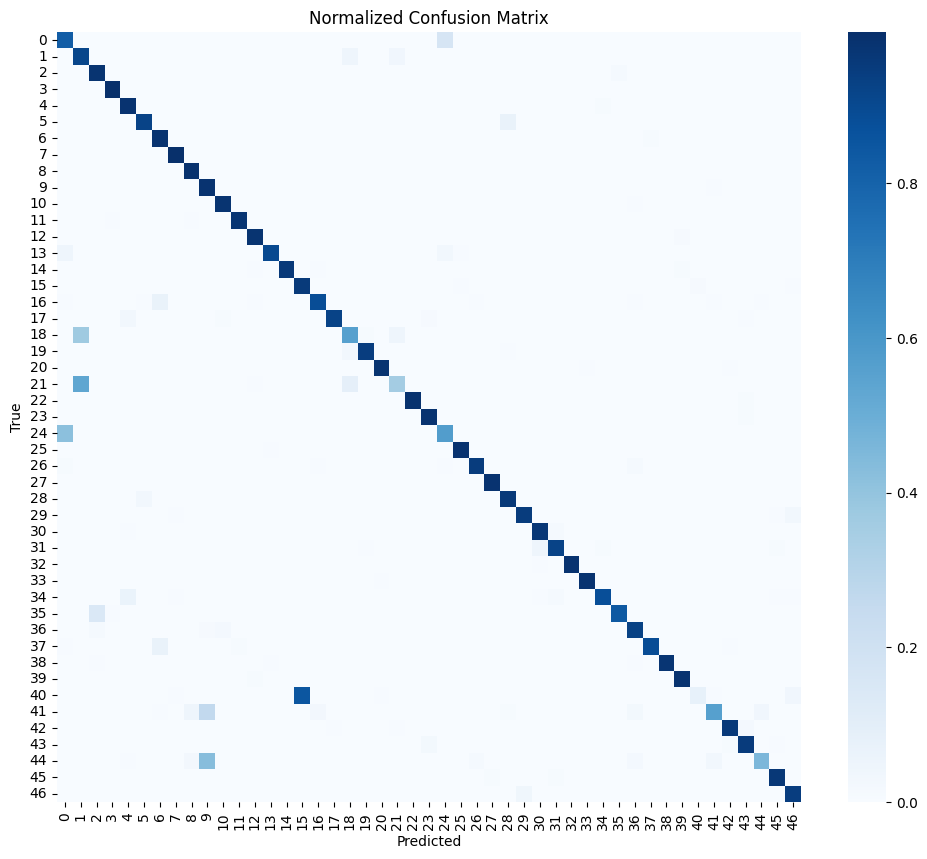

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved Grad-CAM to: /content/drive/MyDrive/cs320/final project/figures/modern_bymerge_gradcam.png


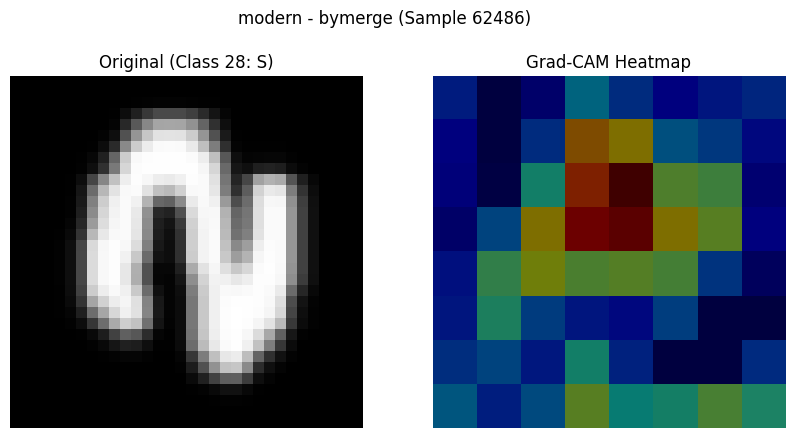

In [ ]:
import torch.nn as nn
import os
import random
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

figures_dir = '/content/drive/MyDrive/cs320/final project/figures/'
os.makedirs(figures_dir, exist_ok=True)

def evaluate_all_models(split_name, model_type):
    print(f'\n--- Evaluating {model_type} Model on: {split_name} ---')
    train_loader, test_loader, num_classes = get_dataloaders(split_name)
    char_names = test_loader.dataset.classes

    if model_type == 'lenet5_rbf':
        model = LeNet5RBF(num_classes).to(device)
    elif model_type == 'resnet':
        model = ResidualCNN(num_classes).to(device)
    elif model_type == 'modern':
        model = ModernCNN(num_classes).to(device)
    else:
        return

    model_path = f'/content/drive/MyDrive/cs320/final project/models/{model_type}_{split_name}_final.pth'

    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))

        # 1. Confusion Matrix
        plot_confusion_matrix(model, test_loader, device, classes=range(num_classes))
        cm_path = os.path.join(figures_dir, f'{model_type}_{split_name}_confusion_matrix.png')
        plt.savefig(cm_path)
        print(f'Saved Confusion Matrix to: {cm_path}')
        plt.show()
        plt.close()

        # 2. Grad-CAM Visualization
        try:
            if model_type == 'resnet':
                target_layer = model.layer3[-1].bn2
            elif model_type == 'modern':
                target_layer = model.bn3
            else:
                target_layer = model.conv2

            cam_tool = GradCAM(model, target_layer)
            dataset = test_loader.dataset
            idx = random.randint(0, len(dataset) - 1)
            img, label_idx = dataset[idx]
            input_img = img.unsqueeze(0).to(device)
            label_char = char_names[label_idx]
            cam = cam_tool.generate(input_img, label_idx)

            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(input_img.squeeze().cpu(), cmap='gray')
            axes[0].set_title(f'Original (Class {label_idx}: {label_char})')
            axes[0].axis('off')
            axes[1].imshow(input_img.squeeze().cpu(), cmap='gray')
            axes[1].imshow(cam, cmap='jet', alpha=0.5)
            axes[1].set_title(f'Grad-CAM Heatmap')
            axes[1].axis('off')
            plt.suptitle(f'{model_type} - {split_name} (Sample {idx})')

            gradcam_path = os.path.join(figures_dir, f'{model_type}_{split_name}_gradcam.png')
            plt.savefig(gradcam_path)
            print(f'Saved Grad-CAM to: {gradcam_path}')
            plt.show()
            plt.close()
        except Exception as e:
            print(f'Grad-CAM failed for {model_type}: {e}')
    else:
        print(f'No weights found for {model_type} at {model_path}.')

# Run evaluation loop
model_types = ['lenet5_rbf', 'resnet', 'modern']
splits = ['balanced', 'byclass', 'bymerge']

for m_type in model_types:
    for s_split in splits:
        evaluate_all_models(s_split, m_type)